In [5]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# 1. 读取数据
file_name = "智慧能源作业.xlsx"
df = pd.read_excel(file_name)

# 查看一下数据的前几行，确保读取正确
print("原始数据预览：")
display(df.head())

# 将'时间'列单独取出来，因为它不是数值，不能参与KNN计算和异常值判定
time_col = df['时间'] 
df_numeric = df.drop(columns=['时间'])

# 检查一下数值列
print("\n数值列预览：")
display(df_numeric.head())

原始数据预览：


,时间,机组冷冻水供水温度（℃）,机组冷冻水回水温度（℃）,冷冻水流量（m³/h）,机组冷却水回水温度（℃）,室外温度（℃）,室内温度（℃）,水泵功率（kw）
0,2024-07-01 00:00:10,9.05,11.58,231.72,27.80,25.36,26.29,22.8
1,2024-07-01 00:10:00,8.44,10.82,231.72,29.67,25.36,26.25,22.8
2,2024-07-01 00:20:00,7.68,10.07,231.72,29.82,25.36,26.28,21.6
3,2024-07-01 00:30:00,6.92,9.15,231.72,29.82,25.21,26.24,20.4
4,2024-07-01 00:40:00,6.17,8.55,231.72,29.52,25.21,26.27,21.6



数值列预览：


,机组冷冻水供水温度（℃）,机组冷冻水回水温度（℃）,冷冻水流量（m³/h）,机组冷却水回水温度（℃）,室外温度（℃）,室内温度（℃）,水泵功率（kw）
0,9.05,11.58,231.72,27.80,25.36,26.29,22.8
1,8.44,10.82,231.72,29.67,25.36,26.25,22.8
2,7.68,10.07,231.72,29.82,25.36,26.28,21.6
3,6.92,9.15,231.72,29.82,25.21,26.24,20.4
4,6.17,8.55,231.72,29.52,25.21,26.27,21.6


In [3]:
# 2.1 记录缺失值的位置（生成一个布尔矩阵，True表示该位置是缺失的）
# 这个掩码用于最后给Excel单元格上色
missing_mask = df_numeric.isna()

# 2.2 使用KNN算法进行填充
# n_neighbors=5 是常用的参数，表示参考最近的5个邻居
knn = KNNImputer(n_neighbors=5)

# 进行填充，fit_transform返回的是numpy数组，需要转回DataFrame
df_filled_data = knn.fit_transform(df_numeric)
df_filled = pd.DataFrame(df_filled_data, columns=df_numeric.columns, index=df_numeric.index)

print("KNN填充完成。")

KNN填充完成。


In [4]:
# 3.1 计算四分位数
Q1 = df_filled.quantile(0.25)
Q3 = df_filled.quantile(0.75)
IQR = Q3 - Q1

# 3.2 定义异常值的上下界
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3.3 识别异常值（生成一个布尔矩阵，True表示该位置是异常值）
# 逻辑：小于下界 或 大于上界 的都是异常值
outlier_mask = (df_filled < lower_bound) | (df_filled > upper_bound)

# 统计一下发现了多少异常值
print(f"共识别出 {outlier_mask.sum().sum()} 个异常数据点。")

共识别出 27 个异常数据点。


In [5]:
# 4.1 将时间列拼回去，得到完整的处理后数据
df_final = df_filled.copy()
df_final.insert(0, '时间', time_col)

# 4.2 定义样式函数
# 这个函数会遍历DataFrame，根据之前生成的 missing_mask 和 outlier_mask 来上色
def highlight_values(data):
    # 创建一个与数据形状相同的空样式DataFrame
    style_df = pd.DataFrame('', index=data.index, columns=data.columns)
    
    # 因为 data 包含了'时间'列，而我们的 mask 是基于 df_numeric 的
    # 所以我们需要只遍历数值列
    numeric_cols = df_numeric.columns
    
    for col in numeric_cols:
        # 1. 标记缺失值 (填充的) -> 黄色
        # 获取该列在 missing_mask 中为 True 的行索引
        missing_indices = missing_mask[col][missing_mask[col]].index
        style_df.loc[missing_indices, col] = 'background-color: yellow'
        
        # 2. 标记异常值 -> 红色
        # 获取该列在 outlier_mask 中为 True 的行索引
        outlier_indices = outlier_mask[col][outlier_mask[col]].index
        style_df.loc[outlier_indices, col] = 'background-color: red'
        
    return style_df

# 4.3 应用样式并导出
output_file = "智慧能源作业_已处理.xlsx"

#以此应用样式
styled_result = df_final.style.apply(highlight_values, axis=None)

# 保存文件
styled_result.to_excel(output_file, index=False, engine='openpyxl')

print(f"处理完成！文件已导出为：{output_file}")
print("其中：\n黄色背景 = 原始缺失值（已用KNN补全）\n红色背景 = 识别出的异常值（IQR法）")

处理完成！文件已导出为：智慧能源作业_已处理.xlsx
其中：
黄色背景 = 原始缺失值（已用KNN补全）
红色背景 = 识别出的异常值（IQR法）


In [6]:
# 读取刚才导出的 '智慧能源作业_已处理.xlsx'
df_final = pd.read_excel("智慧能源作业_已处理.xlsx")

print(f"清洗前数据量: {len(df_final)}")

# 1. 找出物理异常的行：回水温度 <= 供水温度
# 注意：我们要用清洗后的数值列，列名要完全匹配
# 供水: '机组冷冻水供水温度（℃）'
# 回水: '机组冷冻水回水温度（℃）'

supply_col = '机组冷冻水供水温度（℃）'
return_col = '机组冷冻水回水温度（℃）'

# 计算温差
delta_T = df_final[return_col] - df_final[supply_col]

# 找出温差小于等于0的行（物理异常）
abnormal_physics = df_final[delta_T <= 0]

print(f"发现 {len(abnormal_physics)} 条物理逻辑异常数据（回水 <= 供水）。")
print("部分异常数据预览：")
display(abnormal_physics[[supply_col, return_col]].head())

# 2. 剔除这些异常数据，只保留 温差 > 0 的数据
df_clean = df_final[delta_T > 0].copy()

print(f"清洗后数据量: {len(df_clean)}")
print(f"共剔除 {len(df_final) - len(df_clean)} 条数据。")

# 3. 导出最终用于聚类分析的“干净”数据
output_clean_file = "智慧能源作业_聚类清洗版.xlsx"
df_clean.to_excel(output_clean_file, index=False)
print(f"最终清洗数据已保存为: {output_clean_file}")

清洗前数据量: 500
发现 310 条物理逻辑异常数据（回水 <= 供水）。
部分异常数据预览：


,机组冷冻水供水温度（℃）,机组冷冻水回水温度（℃）
7,6.96,6.60
8,6.96,6.60
9,7.41,7.05
10,8.01,7.65
11,8.46,8.10


清洗后数据量: 190
共剔除 310 条数据。
最终清洗数据已保存为: 智慧能源作业_聚类清洗版.xlsx


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

# 1. 读取数据 
file_path = "智慧能源作业_聚类清洗版.xlsx" 
df = pd.read_excel(file_path)

# 2.1 先计算冷负荷 
# 公式：Q = 流量 * (回水 - 供水) * 1.163
if '冷负荷(kW)' not in df.columns:
    df['冷负荷(kW)'] = df['冷冻水流量（m³/h）'] * \
                      (df['机组冷冻水回水温度（℃）'] - df['机组冷冻水供水温度（℃）']) * \
                      1.163
# 2.2 特征选择 
feature_cols = [
    '冷负荷(kW)',      # 反映建筑侧需求
    '室外温度（℃）',   # 反映环境干扰
]

# 检查一下这些列是否都有数据，防止报错
print(f"选定的聚类特征: {feature_cols}")
data_for_cluster = df[feature_cols]

# 3. 数据标准化 (使用 Z-Score)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_cluster)

print("数据标准化完成。")
print("特征矩阵形状:", data_scaled.shape)
print("前5行标准化数据预览:\n", data_scaled[:5])

选定的聚类特征: ['冷负荷(kW)', '室外温度（℃）']
数据标准化完成。
特征矩阵形状: (190, 2)
前5行标准化数据预览:
 [[ 0.74901585 -1.19044763]
 [ 0.33507457 -1.19044763]
 [ 0.36267066 -1.19044763]
 [-0.07886671 -1.23537197]
 [ 0.33507457 -1.23537197]]


正在计算 K=1 到 K=15 的指标，这可能需要几十秒，请稍候...


D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

计算完成，开始绘图。


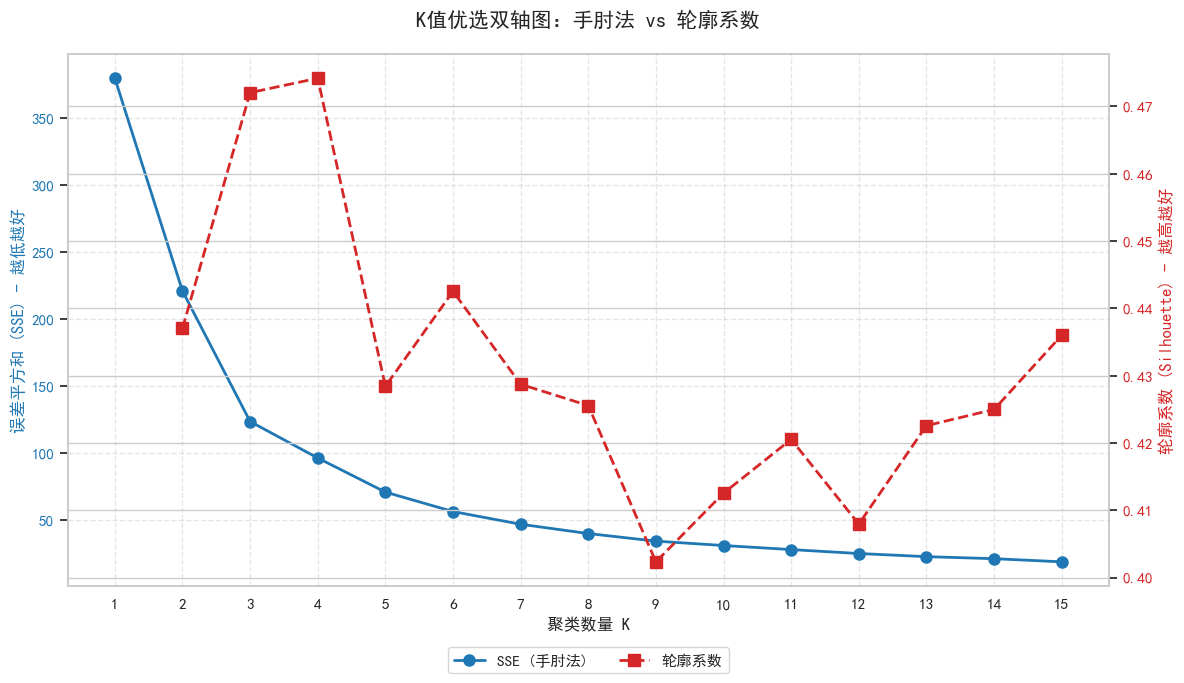

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

try:
    X_input = data_scaled 
except NameError:
    print("错误：找不到 data_scaled 变量，请先运行上一段标准化代码！")
    # 为了防止演示报错，这里生成个随机数占位（实际运行时请忽略这行）
    X_input = np.random.rand(100, 4) 

inertia = []           # 存放手肘法结果
silhouette_scores = [] # 存放轮廓系数
K_range = range(1, 16) # 测试 K = 1 到 15

print(f"正在计算 K=1 到 K=15 的指标，这可能需要几十秒，请稍候...")

for k in K_range:
    # 1. 训练模型
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_input)
    
    # 2. 记录误差平方和 (Inertia)
    inertia.append(kmeans.inertia_)
    
    # 3. 记录轮廓系数 (注意：K=1时无法计算轮廓系数，设为NaN)
    if k > 1:
        score = silhouette_score(X_input, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(np.nan) # K=1时没法算，填空值
    
    # 打印进度（可选）
    # print(f"K={k} 完成")

print("计算完成，开始绘图。")

# ================= 开始画精美图表 =================

# 设置绘图风格
sns.set(style="whitegrid") # 使用白色网格背景
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文
plt.rcParams['axes.unicode_minus'] = False   # 正常显示负号

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- 左轴：手肘法 (蓝色) ---
color_inertia = '#1f77b4' # 经典的深蓝色
ax1.set_xlabel('聚类数量 K', fontsize=12, fontweight='bold')
ax1.set_ylabel('误差平方和 (SSE) - 越低越好', color=color_inertia, fontsize=12, fontweight='bold')
# 画线：带圆点标记，线宽2
ax1.plot(K_range, inertia, marker='o', markersize=8, linestyle='-', linewidth=2, color=color_inertia, label='SSE (手肘法)')
ax1.tick_params(axis='y', labelcolor=color_inertia)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# --- 右轴：轮廓系数 (红色) ---
ax2 = ax1.twinx()  # 创建共享X轴的第二个Y轴
color_sil = '#d62728' # 经典的深红色
ax2.set_ylabel('轮廓系数 (Silhouette) - 越高越好', color=color_sil, fontsize=12, fontweight='bold')
# 画线：带方块标记，线宽2 (注意从K=2开始画，所以数据会自动对其)
ax2.plot(K_range, silhouette_scores, marker='s', markersize=8, linestyle='--', linewidth=2, color=color_sil, label='轮廓系数')
ax2.tick_params(axis='y', labelcolor=color_sil)

# --- 标题与修饰 ---
plt.title('K值优选双轴图：手肘法 vs 轮廓系数', fontsize=15, fontweight='bold', pad=20)
plt.xticks(K_range) # 强制显示1-15的所有刻度

# 添加图例 (合并两个轴的图例有点麻烦，这里用简便方法：在图里加注释或者直接看轴颜色)
# 这里我们在图上方手动添加说明，或者通过代码合并图例：
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=True)

plt.tight_layout() # 自动调整布局防遮挡
plt.show()

正在计算层级聚类链接矩阵（Linkage Matrix），请稍候...


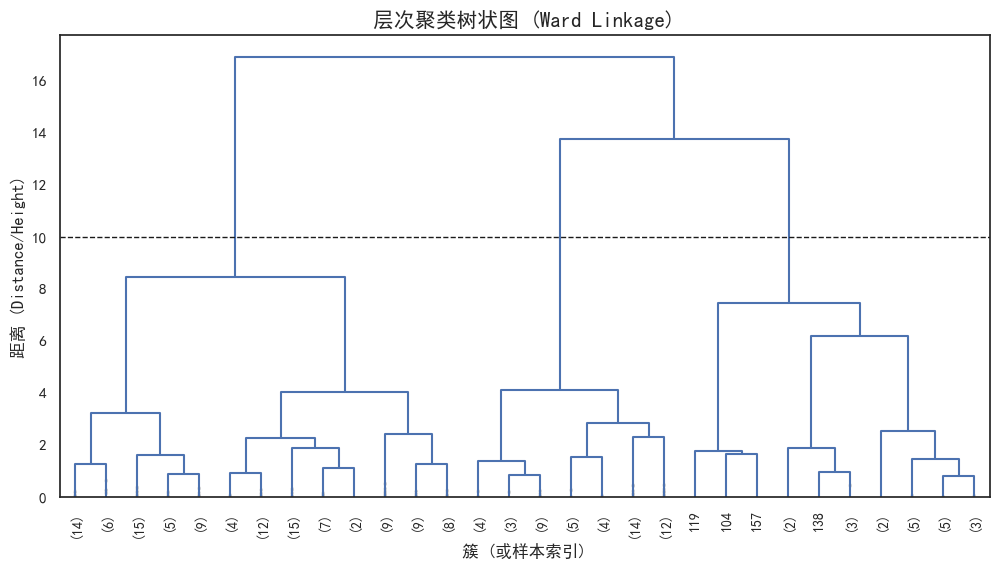

In [8]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# 设置绘图风格
sns.set(style="white") # 树状图通常用白色背景更清晰
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 1. 准备数据
try:
    X_dendro = data_scaled
except NameError:
    print("错误：请先运行之前的标准化(StandardScaler)代码生成 data_scaled！")
    X_dendro = np.random.rand(50, 4) # 占位符

print("正在计算层级聚类链接矩阵（Linkage Matrix），请稍候...")

# 2. 计算链接矩阵 (Linkage)
# method='ward' 是最常用的方法，它试图最小化簇内的方差，效果通常最好
# metric='euclidean' 使用欧氏距离
Z = linkage(X_dendro, method='ward', metric='euclidean')

# 3. 绘制树状图 (Dendrogram)
plt.figure(figsize=(12, 6))

# p=30 表示只显示最后30次合并的过程（也就是树的最顶端），
dendrogram(
    Z,
    truncate_mode='lastp',  # 截断模式：只显示最后的p个合并
    p=30,                   # 显示顶部的30个节点
    leaf_rotation=90.,      # 旋转x轴标签
    leaf_font_size=10.,     # 字体大小
    show_contracted=True,   # 显示被折叠的那些小分支
    color_threshold=0       # 先设为0
)

plt.title('层次聚类树状图 (Ward Linkage)', fontsize=15)
plt.xlabel('簇 (或样本索引)', fontsize=12)
plt.ylabel('距离 (Distance/Height)', fontsize=12)

plt.axhline(y=10, c='k', ls='--', lw=1, label='Cut Line') 

plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# 1. 准备数据
df_result = df_clean.copy() 

if '冷负荷(kW)' not in df_result.columns:
    print("检测到缺少‘冷负荷’列，正在重新计算...")
    df_result['冷负荷(kW)'] = df_result['冷冻水流量（m³/h）'] * \
                              (df_result['机组冷冻水回水温度（℃）'] - df_result['机组冷冻水供水温度（℃）']) * \
                              1.163
else:
    print("‘冷负荷’列已存在，继续执行。")
# ==================================================

# 定义特征列
feature_cols = [
    '冷负荷(kW)', 
    '室外温度（℃）', 
]

# 2. 设置最终的 K 值 ( K=3)
final_k = 3

# 3. 执行 K-Means 聚类
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# 只取需要的列进行标准化
data_scaled_final = scaler.fit_transform(df_result[feature_cols])

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(data_scaled_final)

# 4. 将标签打回数据
df_result['工况标签'] = cluster_labels

# 5. 关键分析：计算每个工况的“平均画像”
# agg函数里：计算均值(mean)、最小值(min)、最大值(max)
summary = df_result.groupby('工况标签')[feature_cols].agg(['mean', 'min', 'max'])

# 加上样本数量统计
summary['样本数量'] = df_result.groupby('工况标签').size()

print("\n>>> 典型工况统计表 (只显示均值以便观察) <<<")
# 只打印 mean (均值) 列，保留2位小数
display(summary.xs('mean', axis=1, level=1).round(2))

# 6. 导出结果
output_file = "智慧能源作业_最终聚类结果.xlsx"
df_result.to_excel(output_file, index=False)
print(f"\n结果已保存至: {output_file}")

检测到缺少‘冷负荷’列，正在重新计算...

>>> 典型工况统计表 (只显示均值以便观察) <<<


D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,冷负荷(kW),室外温度（℃）
工况标签,,
0,630.71,31.96
1,642.45,26.34
2,392.84,32.01



结果已保存至: 智慧能源作业_最终聚类结果.xlsx


C:\Users\shenjing\AppData\Local\Temp\ipykernel_22572\2474689155.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='工况标签', y='冷负荷(kW)', data=df_result, palette='viridis')


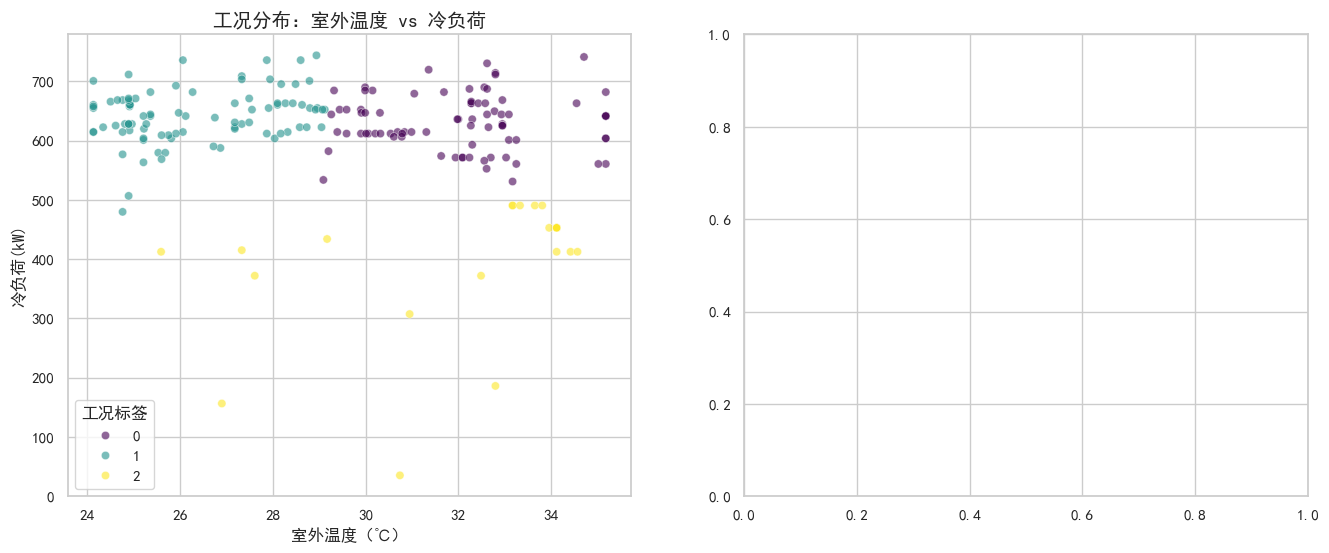

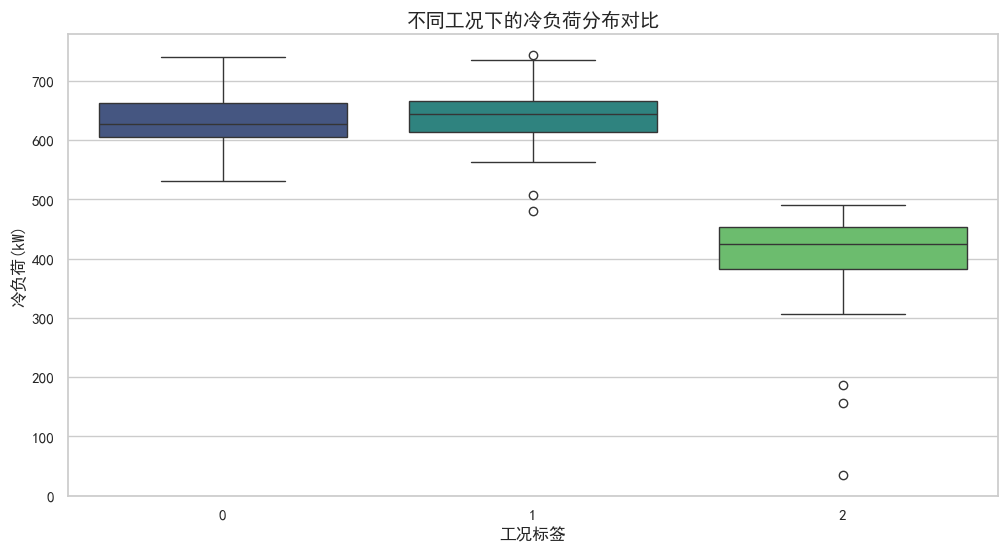

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图1：室外温度 vs 冷负荷 (展示不同天气下的工况分布)
sns.scatterplot(
    data=df_result, 
    x='室外温度（℃）', 
    y='冷负荷(kW)', 
    hue='工况标签', 
    palette='viridis', 
    alpha=0.6, 
    ax=axes[0]
)
axes[0].set_title('工况分布：室外温度 vs 冷负荷', fontsize=14)


# 图3：箱线图 (Boxplot) - 展示各特征在不同工况下的数值范围
# 这是一个非常专业的图表，能看出不同工况的区分度
plt.figure(figsize=(12, 6))
# 为了画在一起，我们需要把数据melt一下（除了工况标签，其他数值归一化或直接画）
# 这里我们直接画原始数值，但因为量纲不同，建议分开看，或者只看最重要的“冷负荷”
sns.boxplot(x='工况标签', y='冷负荷(kW)', data=df_result, palette='viridis')
plt.title('不同工况下的冷负荷分布对比', fontsize=14)
plt.show()

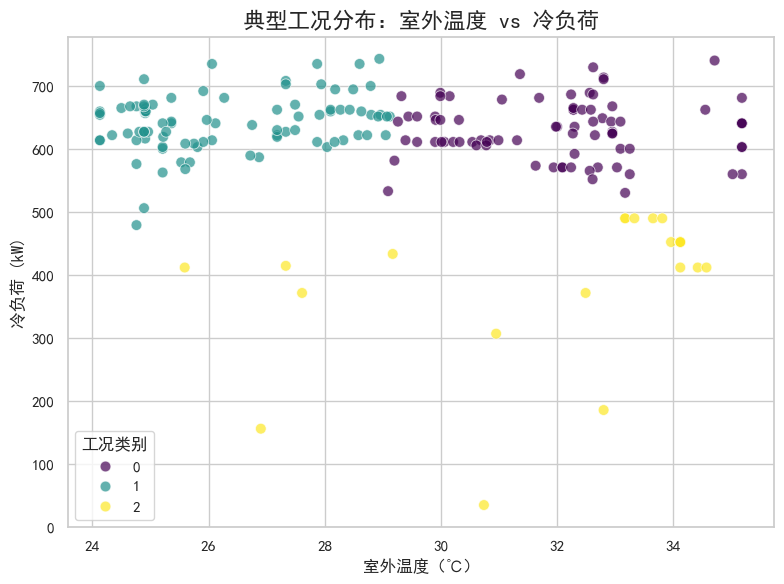

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示

# 创建画布
plt.figure(figsize=(8, 6))

# 绘制散点图
sns.scatterplot(
    data=df_result, 
    x='室外温度（℃）', 
    y='冷负荷(kW)', 
    hue='工况标签',   # 根据聚类结果上色
    palette='viridis', # 配色方案
    s=60,             # 点的大小
    alpha=0.7,        # 透明度，防止点重叠看不清
    edgecolor='w'     # 给点加个白边，更清晰
)

plt.title('典型工况分布：室外温度 vs 冷负荷', fontsize=16)
plt.xlabel('室外温度（℃）', fontsize=12)
plt.ylabel('冷负荷 (kW)', fontsize=12)
plt.legend(title='工况类别')

plt.tight_layout()
plt.show()

C:\Users\shenjing\AppData\Local\Temp\ipykernel_22572\1589362127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\shenjing\AppData\Local\Temp\ipykernel_22572\1589362127.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


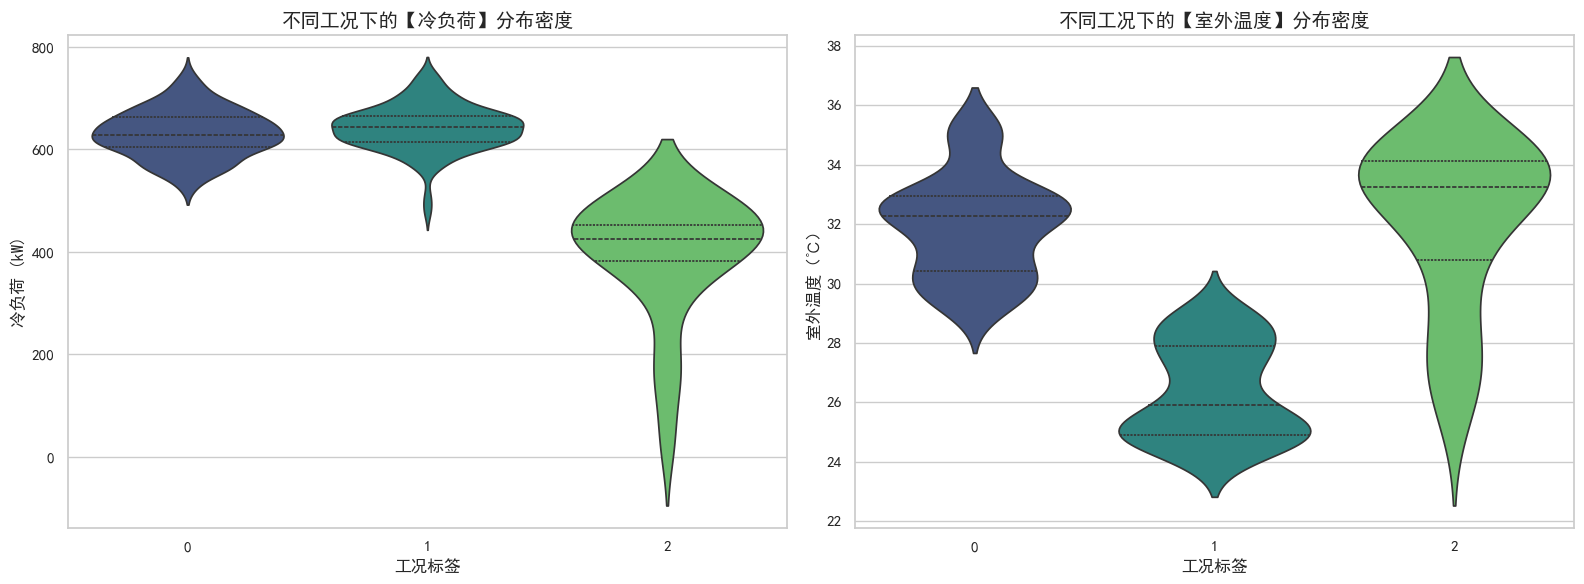

In [16]:
# 创建 1行2列 的画布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 冷负荷的小提琴图
sns.violinplot(
    x='工况标签', 
    y='冷负荷(kW)', 
    data=df_result, 
    palette='viridis', 
    inner='quartile', # 在提琴内部画出四分位数线
    ax=axes[0]
)
axes[0].set_title('不同工况下的【冷负荷】分布密度', fontsize=14)
axes[0].set_xlabel('工况标签')
axes[0].set_ylabel('冷负荷 (kW)')

# 2. 室外温度的小提琴图
sns.violinplot(
    x='工况标签', 
    y='室外温度（℃）', 
    data=df_result, 
    palette='viridis', 
    inner='quartile', 
    ax=axes[1]
)
axes[1].set_title('不同工况下的【室外温度】分布密度', fontsize=14)
axes[1].set_xlabel('工况标签')
axes[1].set_ylabel('室外温度（℃）')

plt.tight_layout()
plt.show()

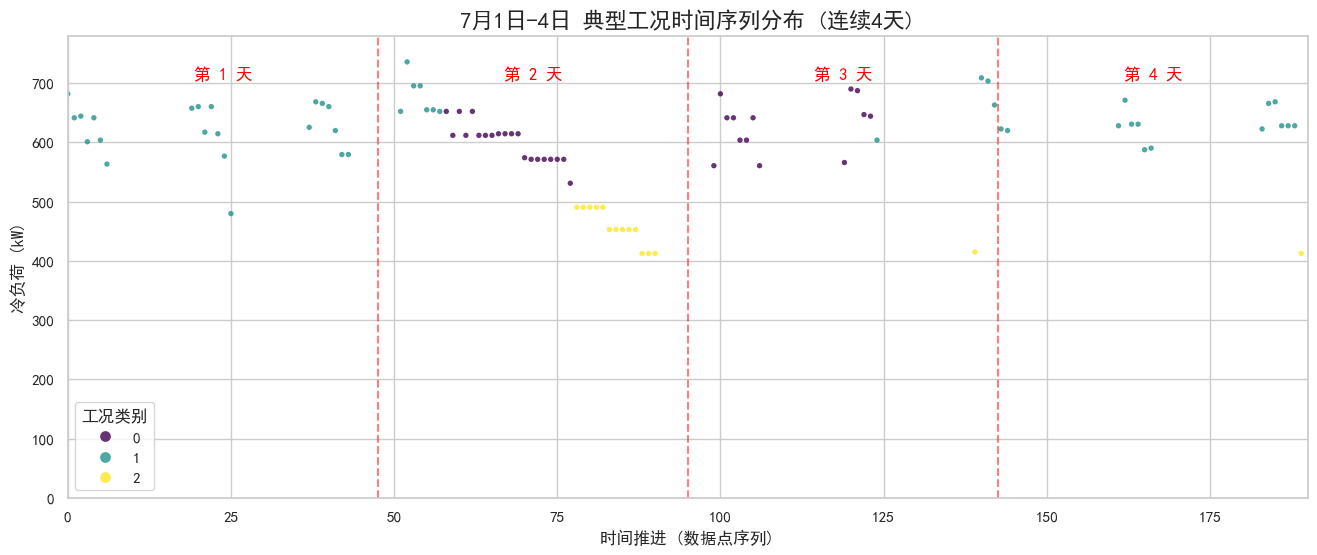

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 核心修正：不进行日期拼接，直接利用行索引作为时间轴
# ==========================================
# 创建一个临时的列 'Time_Step'，就是当前的行号
# 这样 0 代表开始，数据越多时间越往后推，自然就把4天展开了
df_plot = df_result.reset_index().rename(columns={'index': '时间序列'})

# ================= 图4：时间序列分布图 (Time Series Analysis) =================
plt.figure(figsize=(16, 6))

# 绘制散点图
# x轴使用行号，代表时间的连续推进
sns.scatterplot(
    data=df_plot, 
    x='时间序列', 
    y='冷负荷(kW)', 
    hue='工况标签', 
    palette='viridis', 
    s=15,           # 点稍微大一点
    linewidth=0,    # 去掉点的边框，看起来更顺滑
    alpha=0.8       # 透明度
)

# 添加更直观的时间标记（辅助线）
# 假设你的数据是连续的，我们大概把图分成4份，代表4天
total_rows = len(df_plot)
day_length = total_rows / 4

# 画出每天的分界线 (第1天结束, 第2天结束, 第3天结束)
for i in range(1, 4):
    plt.axvline(x=day_length * i, color='red', linestyle='--', alpha=0.5)
    plt.text(day_length * i - (day_length/2), df_plot['冷负荷(kW)'].max()*0.95, 
             f'第 {i} 天', ha='center', color='red', fontsize=12, fontweight='bold')
plt.text(day_length * 4 - (day_length/2), df_plot['冷负荷(kW)'].max()*0.95, 
         '第 4 天', ha='center', color='red', fontsize=12, fontweight='bold')

plt.title('7月1日-4日 典型工况时间序列分布 (连续4天)', fontsize=16)
plt.xlabel('时间推进 (数据点序列)', fontsize=12)
plt.ylabel('冷负荷 (kW)', fontsize=12)
plt.legend(title='工况类别',  markerscale=2)
plt.xlim(0, total_rows) # 限制X轴范围
plt.show()